<a href="https://colab.research.google.com/github/Anshu-kumar-singh/Production-RAG-CRAG-Self-RAG-Evaluation/blob/main/crag_self_rag_merged.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importing the req thing and env file data
from typing import List, TypedDict, Literal
from pydantic import BaseModel
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()

True

In [ ]:
# Data + Index

# loading 3 doc with help of pdf loader
docs = (
    PyPDFLoader("./documents/book1.pdf").load()
    + PyPDFLoader("./documents/book2.pdf").load()
    + PyPDFLoader("./documents/book3.pdf").load()
)

In [ ]:
# text splitting
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")


In [ ]:
# Embedding
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings) # storing it in vector store
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4}) #retriver


In [ ]:
# loading the model
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [ ]:
# deciding the uppder limit and lower limit so we can differentiate btw correct and incorrect
UPPER_TH = 0.7
LOWER_TH = 0.3

In [ ]:

# State
class State(TypedDict):
    question: str # Stores the user's original question

    docs: List[Document] # Stores all documents retrieved from the vector database.
    good_docs: List[Document] # After retrieval, CRAG evaluates every document.

    verdict: str # Stores the final quality judgment.
    reason: str # Stores why the evaluator gave that verdict.

    strips: List[str] # CRAG doesn't immediately use whole documents. (It breaks documents into small sentences or strips.)
    kept_strips: List[str] #Each strip is evaluated individually. (Irrelevant strips are removed.)
    refined_context: str # After selecting useful strips, they are joined together into one context.

    web_query: str # CRAG rewrites the user's question into a better web search query.

    web_docs: List[Document]

    answer: str

    # ---- Self-RAG additions (front gate) ----
    need_retrieval: bool # whether the front gate decided we even need retrieval

    # ---- Self-RAG additions (back-end verification loop) ----
    issup: Literal["fully_supported", "partially_supported", "no_support"] # is the answer grounded in refined_context
    evidence: List[str] # quotes from refined_context backing the answer
    retries: int # how many times revise_answer has run

    isuse: Literal["useful", "not_useful"] # does the answer actually satisfy the question
    use_reason: str # short reason for the isuse verdict
    rewrite_tries: int # how many times we've looped back through rewrite_query on a not_useful verdict


In [ ]:
# -----------------------------
# Self-RAG front gate: decide if retrieval is needed at all
# -----------------------------
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON with key: should_retrieve (boolean).\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts from the source documents.\n"
            "- should_retrieve=False for general explanations/definitions.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

# the variable decision is of type RetrieveDecision.
def decide_retrieval(state: State) -> State:# ********** Note this type of invoking .
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}
# ************note this way of directing .
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]: # This function doesn't go anywhere itself. Instead, it tells LangGraph which node to execute next.
    return "retrieve" if state["need_retrieval"] else "generate_direct"


In [ ]:
# -----------------------------
# Self-RAG front gate: direct answer, no retrieval needed
# -----------------------------
direct_generation_prompt = ChatPromptTemplate.from_messages( #**** note this is form_message not prompt_template .
    [
        (
            "system",
            "Answer using only your general knowledge.\n"
            "If it requires specific source-document info, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate_direct(state: State) -> State:
    out = llm.invoke(direct_generation_prompt.format_messages(question=state["question"]))
    return {"answer": out.content}


In [ ]:

# Retrieve as per q
def retrieve_node(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}  # we get the query from question state and use that for retriving the data


In [ ]:
# Score-based doc evaluator

class DocEvalScore(BaseModel): # This Creates a structured output format. (froceing the llm to give the out put in this formate only )
    score: float # stores relevance score.
    reason: str # stores explanation.


doc_eval_prompt = ChatPromptTemplate.from_messages(  # Creates a LangChain prompt.
    [
        (
            "system", # System instructions for the LLM.
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"), # what i should write chat gpt
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore) # making chain and giving it to llm


def eval_each_doc_node(state: State) -> State:
    q = state["question"] # get the question
    scores: List[float] = [] #empty list store score
    good: List[Document] = [] # Store useful docs.

    for d in state["docs"]: # Loop Through Retrieved Docs
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content}) # LLM evaluates chunk.(return the score and reason as we have mention previously )
        scores.append(out.score) # Save Score

        # Store useful documents.(bec we want the value which are greater the lowe threshold)
        if out.score > LOWER_TH:
            good.append(d)
    #------------X---------------
    # This line we update the state while comparing the result with threshold
    # CORRECT: at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # INCORRECT: all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}.",
        }

    # AMBIGUOUS: otherwise
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}.",
    }


In [ ]:

# Sentence-level DECOMPOSER


# this part splits the retrived sentence into parts.
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

# FILTER (LLM judge)
class KeepOrDrop(BaseModel):
    keep: bool # llm must return the ans true or false only


filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop) # it remove the sentance which are not usefull according to the query


# -----------------------------
# Knowledge refinement
# (CORRECT => internal only)
# (INCORRECT => web only)
# (AMBIGUOUS => internal + web)
# -----------------------------

# This node is basically a context cleaner.
# It takes the selected documents, breaks them into sentences, removes irrelevant sentences using an LLM filter, and returns a clean context for answer generation.

def refine(state: State) -> State:
    q = state["question"]

    # Choose which documents to use.
    if state.get("verdict") == "CORRECT":
        docs_to_use = state["good_docs"]   # Use only retrieved docs.
    elif state.get("verdict") == "INCORRECT":
        docs_to_use = state["web_docs"]   # Use only web search results.
    else:  # AMBIGUOUS
        docs_to_use = state["good_docs"] + state["web_docs"] # For AMBIGUOUS, combine both.

    context = "\n\n".join(d.page_content for d in docs_to_use).strip() # Merge all document text into one big string.

    strips = decompose_to_sentences(context)  # Convert the big text into individual sentences.

    kept: List[str] = [] # Create an empty list for useful sentences.
    for s in strips: # Loop through every sentence.
        if filter_chain.invoke({"question": q, "sentence": s}).keep:  # Does this sentence help answer the question?
            kept.append(s)

    refined_context = "\n".join(kept).strip() # Combine the kept sentences into a final clean context.

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }


* First, the retrieved document chunks are combined and then split into individual sentences. Each sentence is evaluated by the LLM to determine whether it is relevant to the user's question. Relevant sentences are kept, while irrelevant ones are discarded. The remaining sentences are merged to create a refined context that is used for the final answer generation.

In [ ]:
# -----------------------------
# Query rewrite for web search
# -----------------------------
class WebQuery(BaseModel):
    query: str


rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)


def rewrite_query_node(state: State) -> State: # Creates a LangGraph node.
    out = rewrite_chain.invoke({"question": state["question"]}) # Takes the user's question and sends it to the query-rewriter LLM.
    # ✅ Self-RAG addition: track how many times IsUSE has sent us back here
    return {"web_query": out.query, "rewrite_tries": state.get("rewrite_tries", 0) + 1}


# -----------------------------
# Web search node: uses web_query
# -----------------------------
tavily = TavilySearchResults(max_results=5) # create a tavily search tool


def web_search_node(state: State) -> State:
    q = state.get("web_query") or state["question"] # getting the search query (if we got the web querry then q is a web querry else q is the main query )
    results = tavily.invoke({"query": q}) # Send query to Tavily.

    web_docs: List[Document] = [] # Store search results as LangChain Documents.
    for r in results or []: # Loop through every search result.
        title = r.get("title", "") # Extract Title
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")  # Take content if available.else use snippet(what is ...)
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}" #buliding the text (i guess it mean writing the text in proper way )
        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title})) # Convert search result into a LangChain Document.

    return {"web_docs": web_docs}


/var/folders/h1/gh59pbb174b94mbxsb8xb9qc0000gn/T/ipykernel_70086/4242330831.py:34: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=5)


In [ ]:
# -----------------------------
# Generate
# Everything before this node was preparing clean context.
# Creates the final prompt.
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)


def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "context": state["refined_context"]})
    return {"answer": out.content}


In [ ]:
# -----------------------------
# Self-RAG back-end check 1: IsSUP (is the answer grounded in refined_context?)
# -----------------------------
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported: every meaningful claim is explicitly supported by CONTEXT.\n"
            "- partially_supported: core facts are supported, but the ANSWER adds interpretation/abstraction not in CONTEXT.\n"
            "- no_support: key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: any unsupported qualitative phrasing -> partially_supported.\n"
            "- Evidence: up to 3 short direct quotes from CONTEXT.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{refined_context}\n"
        ),
    ]
)

issup_llm = llm.with_structured_output(IsSUPDecision)

def is_sup(state: State) -> State:
    decision: IsSUPDecision = issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            refined_context=state.get("refined_context", ""),
        )
    )
    return {"issup": decision.issup, "evidence": decision.evidence}


MAX_RETRIES = 3

def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    if state.get("issup") == "fully_supported":
        return "accept_answer"
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"  # give up revising, let IsUSE have the final say
    return "revise_answer"


In [ ]:
# -----------------------------
# Self-RAG back-end check 1b: revise_answer (quote-only rewrite from refined_context)
# -----------------------------
def accept_answer(state: State) -> State:
    return {}  # keep answer as-is

revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{refined_context}"
        ),
    ]
)

def revise_answer(state: State) -> State:
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            refined_context=state.get("refined_context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,
    }


In [ ]:
# -----------------------------
# Self-RAG back-end check 2: IsUSE (does the answer actually satisfy the question?)
# -----------------------------
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: the answer directly answers the question or gives the requested specific info.\n"
            "- not_useful: the answer is generic, off-topic, or only background without answering.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        ("human", "Question:\n{question}\n\nAnswer:\n{answer}"),
    ]
)

isuse_llm = llm.with_structured_output(IsUSEDecision)

def is_use(state: State) -> State:
    decision: IsUSEDecision = isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
        )
    )
    return {"isuse": decision.isuse, "use_reason": decision.reason}


MAX_REWRITE_TRIES = 3

def route_after_isuse(state: State) -> Literal["END", "rewrite_query"]:
    # not_useful -> loop back into CRAG's own correction cycle:
    # rewrite_query -> web_search -> refine -> generate
    if state.get("isuse") == "useful":
        return "END"
    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "END"  # give up, keep best-effort answer
    return "rewrite_query"


In [ ]:
# -----------------------------
# Routing
# CORRECT => refine
# INCORRECT / AMBIGUOUS => rewrite -> web_search -> refine -> generate
# -----------------------------
def route_after_eval(state: State) -> str: # This is the router function. It decides which node runs next.
    if state["verdict"] == "CORRECT":
        return "refine"
    else:
        return "rewrite_query"


In [ ]:
# -----------------------------
# Build graph (CRAG core + Self-RAG front gate + back-end verification loop)
# -----------------------------
g = StateGraph(State)

# Self-RAG front gate
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)

# CRAG core (unchanged)
g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)
g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)
g.add_node("refine", refine)
g.add_node("generate", generate)

# Self-RAG back-end verification loop
g.add_node("is_sup", is_sup)
g.add_node("accept_answer", accept_answer)
g.add_node("revise_answer", revise_answer)
g.add_node("is_use", is_use)

# --------------------
# Front gate edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {"generate_direct": "generate_direct", "retrieve": "retrieve"},
)

g.add_edge("generate_direct", END)

# --------------------
# CRAG core edges (unchanged)
# --------------------
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",
        "rewrite_query": "rewrite_query",
    },
)

g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "refine")
g.add_edge("refine", "generate")

# --------------------
# Back-end verification edges
# --------------------
g.add_edge("generate", "is_sup")

g.add_conditional_edges(
    "is_sup",
    route_after_issup,
    {
        "accept_answer": "accept_answer",
        "revise_answer": "revise_answer",
    },
)

g.add_edge("accept_answer", "is_use")
g.add_edge("revise_answer", "is_sup")  # loop back to re-check support

g.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "END": END,
        # not_useful -> back into CRAG's own correction cycle (full re-correction)
        "rewrite_query": "rewrite_query",
    },
)

app = g.compile()

app


In [ ]:
# -----------------------------
# Run example
# -----------------------------
res = app.invoke(
    {
        "question": "Batch normalization vs layer normalization",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_query": "",
        "web_docs": [],
        "answer": "",

        # Self-RAG additions
        "need_retrieval": True,
        "issup": "",
        "evidence": [],
        "retries": 0,
        "isuse": "",
        "use_reason": "",
        "rewrite_tries": 0,
    },
    config={"recursion_limit": 80},  # allow revise / re-correction loops
)

print("NEED_RETRIEVAL:", res.get("need_retrieval"))
print("VERDICT:", res.get("verdict"))
print("REASON:", res.get("reason"))
print("WEB_QUERY:", res.get("web_query"))
print("ISSUP:", res.get("issup"), "| retries:", res.get("retries"))
print("ISUSE:", res.get("isuse"), "| reason:", res.get("use_reason"), "| rewrite_tries:", res.get("rewrite_tries"))
print("\nOUTPUT:\n", res.get("answer"))


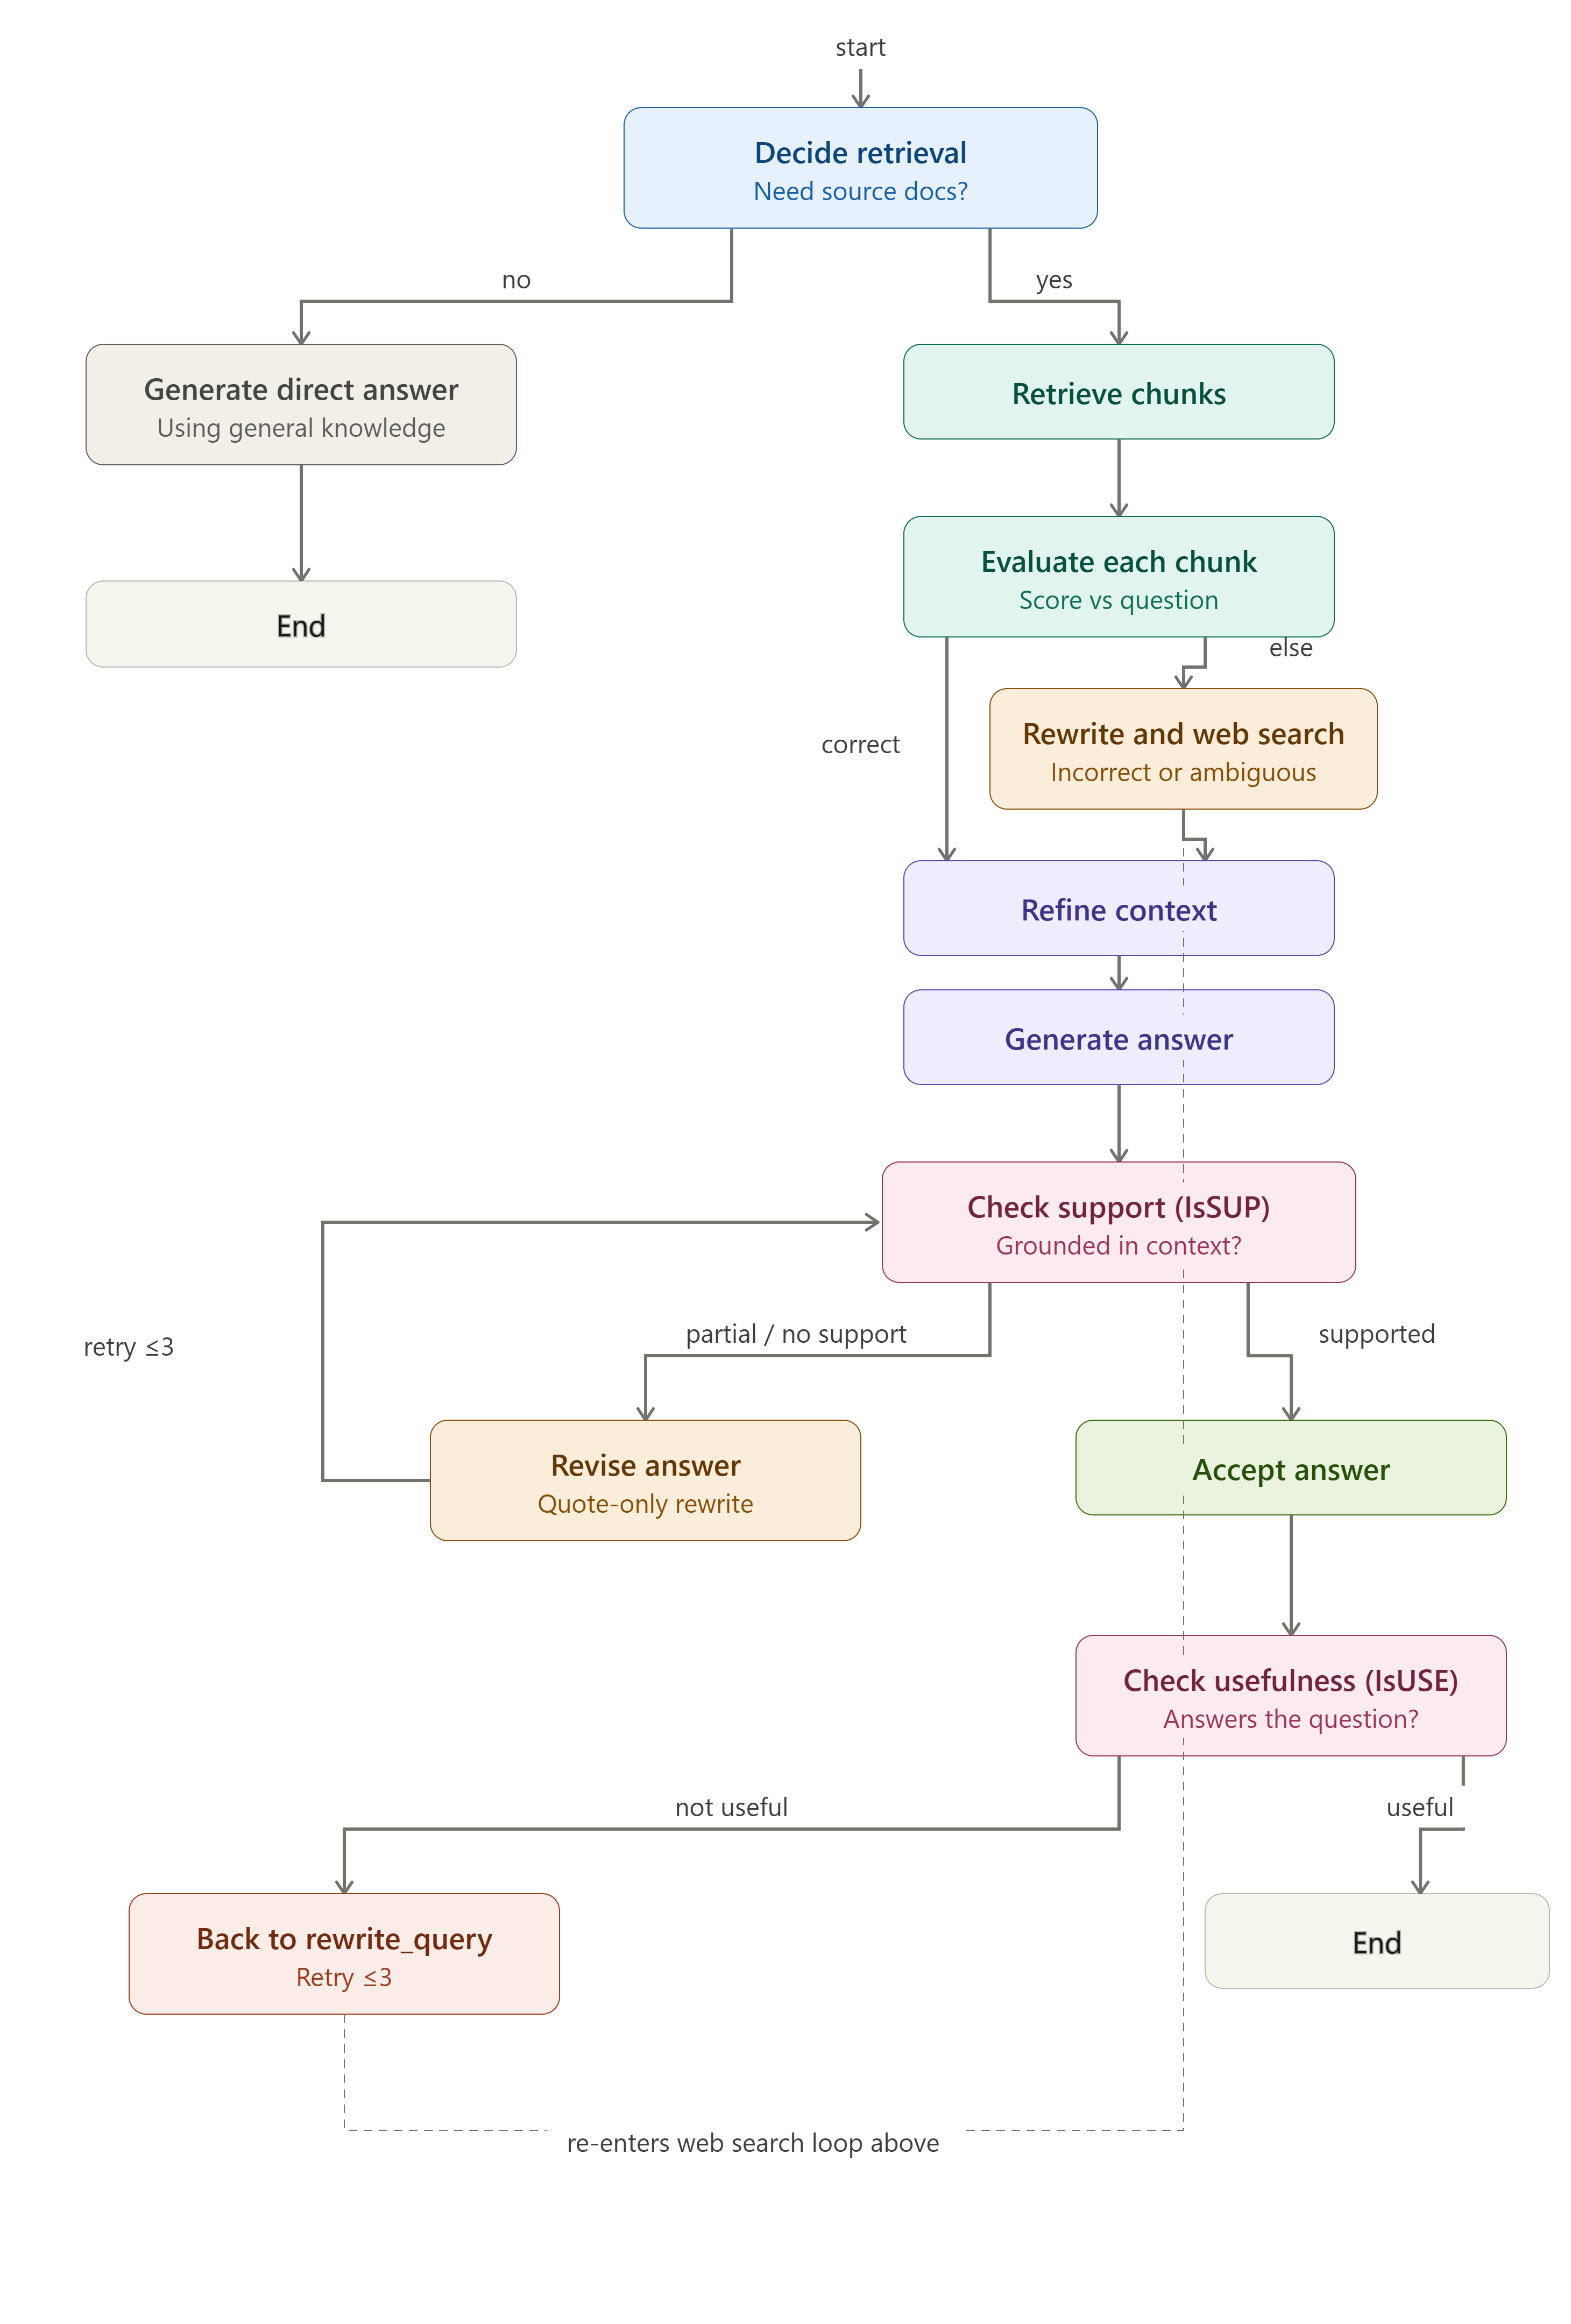